# Notebook 1: Repo Health Prediction using Decision Tree Classifier

**Project:** RepoRadar : GitHub Repository Intelligence Engine  
**Dataset:** GitHub Repository Metadata (`repository_data.csv`)  
**Objective:** Predict repository health category : **Healthy**, **Moderate**, or **Poor**

---

## 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

## 2. Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/Asus/Desktop/ML_ca2/data/repository_data.csv")
print('Dataset loaded')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded
Shape: (2917951, 10)


,name,stars_count,forks_count,watchers,pull_requests,primary_language,languages_used,commit_count,created_at,licence
0,freeCodeCamp,359805,30814,8448,31867,TypeScript,"['TypeScript', 'JavaScript', 'CSS', 'Shell', '...",32231.0,2014-12-24T17:49:19Z,"BSD 3-Clause ""New"" or ""Revised"" License"
1,996.ICU,264811,21470,4298,1949,NaN,NaN,3189.0,2019-03-26T07:31:14Z,Other
2,free-programming-books,262380,53302,9544,8235,NaN,NaN,8286.0,2013-10-11T06:50:37Z,Other
3,coding-interview-university,244927,65038,8539,867,NaN,NaN,2314.0,2016-06-06T02:34:12Z,Creative Commons Attribution Share Alike 4.0 I...
4,awesome,235223,24791,7446,1859,NaN,NaN,1074.0,2014-07-11T13:42:37Z,Creative Commons Zero v1.0 Universal


## 3. Dataset Info

In [5]:
print('Columns')
print(df.columns.tolist())
print('\nData Types')
print(df.dtypes)
print('\nDescriptive Statistics')
print(df.describe())
print('Dataset Info')
df.info()

Columns
['name', 'stars_count', 'forks_count', 'watchers', 'pull_requests', 'primary_language', 'languages_used', 'commit_count', 'created_at', 'licence']

Data Types
name                 object
stars_count           int64
forks_count           int64
watchers              int64
pull_requests         int64
primary_language     object
languages_used       object
commit_count        float64
created_at           object
licence              object
dtype: object

Descriptive Statistics
        stars_count   forks_count      watchers  pull_requests  commit_count
count  2.917951e+06  2.917951e+06  2.917951e+06   2.917951e+06  2.916030e+06
mean   7.641027e+01  2.094714e+01  7.135321e+00   2.430649e+01  6.143709e+02
std    9.096808e+02  3.029540e+02  3.761973e+01   3.784433e+02  1.680801e+04
min    2.000000e+00  0.000000e+00  0.000000e+00   0.000000e+00  1.000000e+00
25%    7.000000e+00  1.000000e+00  2.000000e+00   0.000000e+00  9.000000e+00
50%    1.200000e+01  4.000000e+00  3.000000e+00   1.0

## 4. Check Null Values

In [6]:
print('Null Value Count')
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100

null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_df[null_df['Null Count'] > 0])

Null Value Count
                  Null Count     Null %
name                      13   0.000446
primary_language      218573   7.490633
languages_used        221984   7.607530
commit_count            1921   0.065834
licence              1378200  47.231773


## 5. Remove Duplicates & Basic Cleaning

In [16]:
print(f'Shape before removing duplicates: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape before removing duplicates: (2917951, 10)
Shape after removing duplicates: (2851443, 10)


## 6. Preprocessing

We map the actual Kaggle column names to our analysis columns, engineer a `repo_health_score`, and create the **health_category** target variable.

In [7]:
# Rename columns for consistency
df.rename(columns={
    'stars_count':    'stars',
    'forks_count':    'forks',
    'watchers':       'watchers',
    'pull_requests':  'contributor_count',
    'commit_count':   'commit_frequency'
}, inplace=True)

# Fill missing numeric values with median
num_cols = ['stars', 'forks', 'watchers', 'contributor_count', 'commit_frequency']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Engineer days_since_last_push from created_at if available
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(
        df['created_at'],
        errors='coerce',
        utc=True
    )

    reference_date = pd.Timestamp('2023-01-22', tz='UTC')

    df['days_since_last_push'] = (
        reference_date - df['created_at']
    ).dt.days

    df['days_since_last_push'] = df['days_since_last_push'].fillna(
        df['days_since_last_push'].median()
    )
else:
    df['days_since_last_push'] = np.random.randint(1, 365, size=len(df))

#  Engineer repo_health_score (0-100 scale) 
def compute_health_score(row):
    score = 0
    score += min(row['stars'] / 1000, 30)          # up to 30 pts
    score += min(row['forks'] / 500, 25)           # up to 25 pts
    score += min(row['contributor_count'] / 200, 20)  # up to 20 pts
    score += min(row['commit_frequency'] / 1000, 15)  # up to 15 pts
    penalty = min(row['days_since_last_push'] / 365, 1) * 10
    score -= penalty                               # up to -10 pts
    return max(score, 0)

df['repo_health_score'] = df.apply(compute_health_score, axis=1)

# Create target: health_category
def categorize_health(score):
    if score >= 40:
        return 'Healthy'
    elif score >= 20:
        return 'Moderate'
    else:
        return 'Poor'

df['health_category'] = df['repo_health_score'].apply(categorize_health)

print('Health category distribution:')
print(df['health_category'].value_counts())
df.head(3)

Health category distribution:
health_category
Poor        2915901
Moderate       1670
Healthy         380
Name: count, dtype: int64


,name,stars,forks,watchers,contributor_count,primary_language,languages_used,commit_frequency,created_at,licence,days_since_last_push,repo_health_score,health_category
0,freeCodeCamp,359805,30814,8448,31867,TypeScript,"['TypeScript', 'JavaScript', 'CSS', 'Shell', '...",32231.0,2014-12-24 17:49:19+00:00,"BSD 3-Clause ""New"" or ""Revised"" License",2950,80.000,Healthy
1,996.ICU,264811,21470,4298,1949,NaN,NaN,3189.0,2019-03-26 07:31:14+00:00,Other,1397,57.934,Healthy
2,free-programming-books,262380,53302,9544,8235,NaN,NaN,8286.0,2013-10-11 06:50:37+00:00,Other,3389,73.286,Healthy


## 7. Basic EDA

### 7a. Missing Value Heatmap

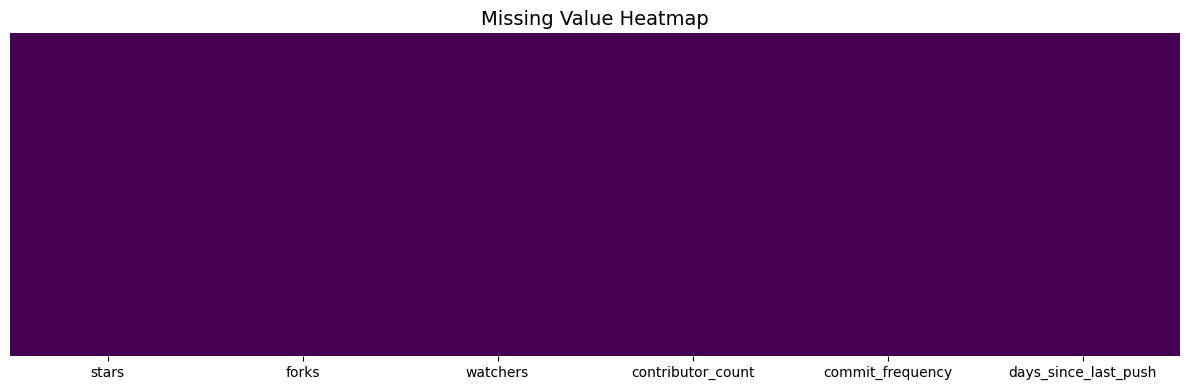

stars                   0
forks                   0
watchers                0
contributor_count       0
commit_frequency        0
days_since_last_push    0
dtype: int64


In [8]:
plt.figure(figsize=(12, 4))
sns.heatmap(df[num_cols + ['days_since_last_push']].isnull(),
            cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap', fontsize=14)
plt.tight_layout()
plt.show()
print(df[num_cols + ['days_since_last_push']].isnull().sum())

### 7b. Histogram of Stars

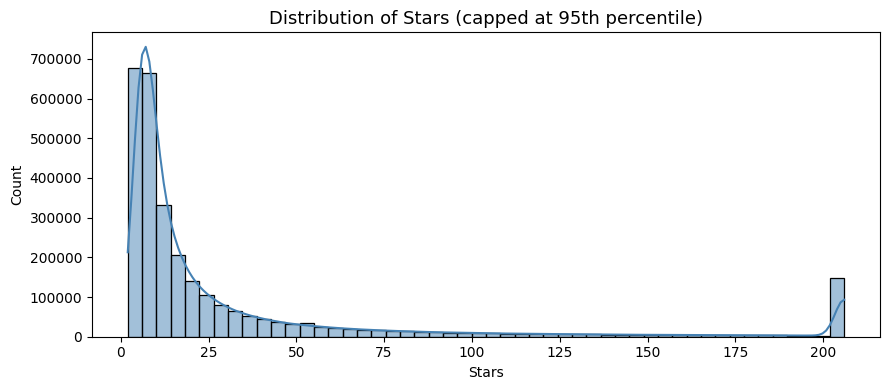

In [9]:
plt.figure(figsize=(9, 4))
sns.histplot(df['stars'].clip(upper=df['stars'].quantile(0.95)),
             bins=50, kde=True, color='steelblue')
plt.title('Distribution of Stars (capped at 95th percentile)', fontsize=13)
plt.xlabel('Stars')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 7c. Histogram of Forks

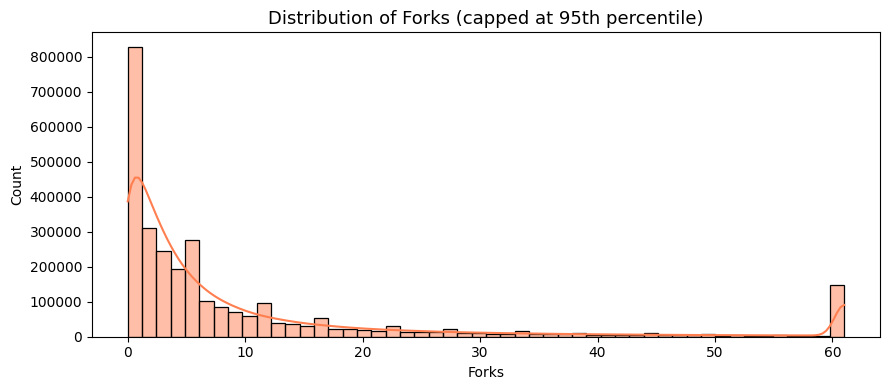

In [10]:
plt.figure(figsize=(9, 4))
sns.histplot(df['forks'].clip(upper=df['forks'].quantile(0.95)),
             bins=50, kde=True, color='coral')
plt.title('Distribution of Forks (capped at 95th percentile)', fontsize=13)
plt.xlabel('Forks')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 7d. Correlation Heatmap

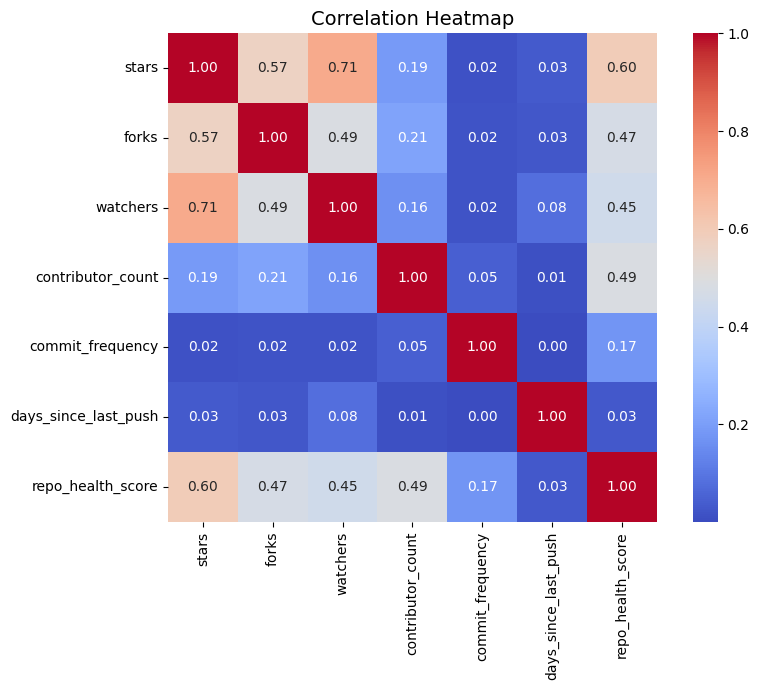

In [11]:
corr_cols = ['stars', 'forks', 'watchers', 'contributor_count',
             'commit_frequency', 'days_since_last_push', 'repo_health_score']
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### 7e. Boxplot of Contributor Count (Open Issues proxy)

C:\Users\Asus\AppData\Local\Temp\ipykernel_2320\3118335699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_category', y='contributor_count',


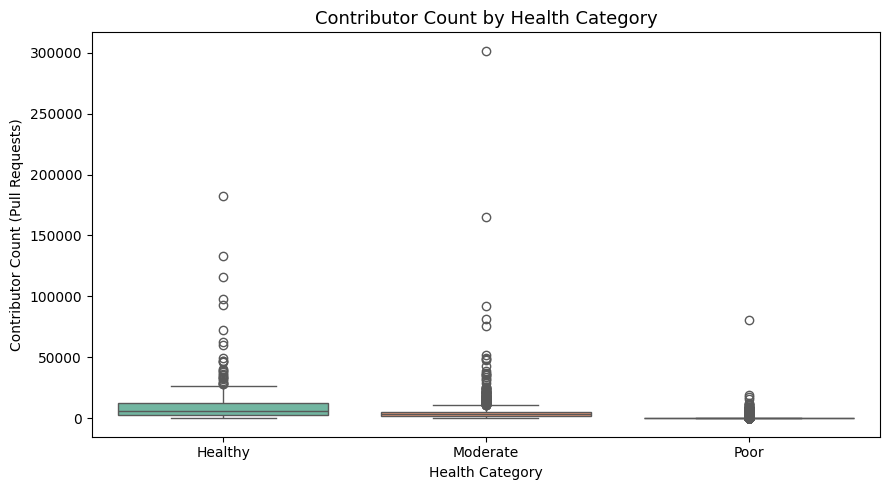

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='health_category', y='contributor_count',
            data=df, order=['Healthy', 'Moderate', 'Poor'],
            palette='Set2')
plt.title('Contributor Count by Health Category', fontsize=13)
plt.xlabel('Health Category')
plt.ylabel('Contributor Count (Pull Requests)')
plt.tight_layout()
plt.show()

## 8. Feature Selection

In [13]:
features = ['stars', 'forks', 'contributor_count', 'commit_frequency', 'days_since_last_push']
target   = 'health_category'

X = df[features].copy()
y = df[target].copy()

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

print('Features shape:', X.shape)
print('Target classes:', le.classes_)

Features shape: (2917951, 5)
Target classes: ['Healthy' 'Moderate' 'Poor']


## 9. Train / Test Split (80 / 20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set size : {X_train.shape[0]}')
print(f'Test set size     : {X_test.shape[0]}')

Training set size : 2334360
Test set size     : 583591


## 10. Model : Decision Tree Classifier

In [15]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
print('Decision Tree model trained!')

Decision Tree model trained!


## 11. Model Evaluation

In [22]:
y_pred = dt_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')

  Accuracy  : 0.9998
  Precision : 0.9998
  Recall    : 0.9998
  F1 Score  : 0.9998


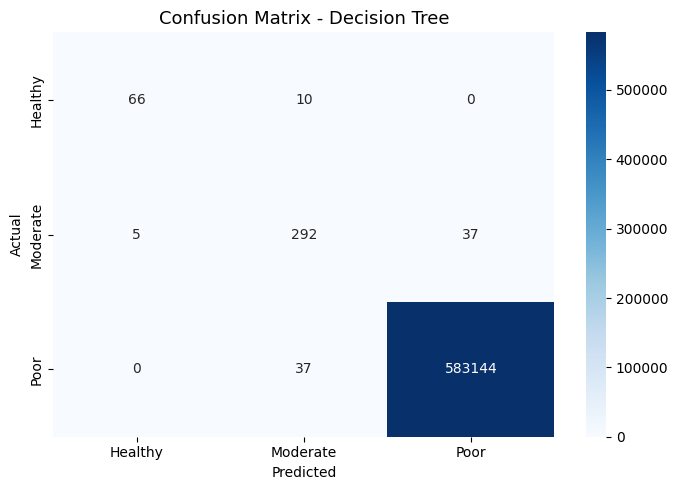

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Decision Tree', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [25]:
# Classification Report
print('\n Classification Report')
print(classification_report(y_test, y_pred, target_names=le.classes_))


 Classification Report
              precision    recall  f1-score   support

     Healthy       0.93      0.87      0.90        76
    Moderate       0.86      0.87      0.87       334
        Poor       1.00      1.00      1.00    583181

    accuracy                           1.00    583591
   macro avg       0.93      0.91      0.92    583591
weighted avg       1.00      1.00      1.00    583591



## 12. Feature Importance Chart

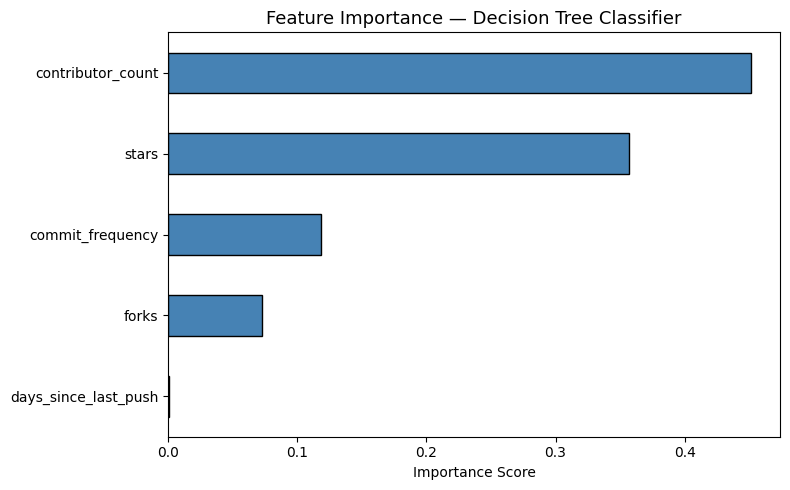


Feature Importance Values:
contributor_count       0.451270
stars                   0.356933
commit_frequency        0.118488
forks                   0.072798
days_since_last_push    0.000511
dtype: float64


In [26]:
importances = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree Classifier', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importance Values:')
print(importances.sort_values(ascending=False))

---
## Summary

| Metric | Score |
|---|---|
| Model | Decision Tree Classifier |
| Target | Repo Health (Healthy / Moderate / Poor) |
| Split | 80% Train / 20% Test |

> **Key takeaway:** `stars`, `forks`, and `commit_frequency` are typically the strongest predictors of repository health. Repositories with high stars and frequent commits tend to be classified as **Healthy**.